In [4]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import os
import glob

import sys
sys.path.insert(1, './src')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Load Diffusion pipeline

In [6]:
from custom_unet_cond import *
from utils_lidc import *

exp_id = "2024-07-13_10-10-26_FINAL_CCIA24_model1_selfattention_locmask"
#exp_id = "2024-07-12_19-57-59_FINAL_CCIA24_model3_crossattention_locmask_noduleattributes_maskv2"
#exp_id = "2024-07-12_10-03-18_FINAL_CCIA24_model2_crossattention_locmask_maskv2"ç
exp_id = "2024-07-16_15-47-32_FINAL_CCIA24_model3_crossattention_locmask_noduleattributes_maskv2"
exp_id = "2024-07-17_19-01-16_FINAL_CCIA24_model3_crossattention_locmask_noduleattributes_maskv2"
model_path = f"/media/share/Datasets/diffusers_out/{exp_id}"
dataset_name = "/home/ubuntu/projects/phase-iv-ai/DiffusionFastForward/paper_dataset_all/nodules_6mm_512x512"

pipeline = load_pipeline(model_path, dataset_name)

Loading Diffusion pipeline from:
    - /media/share/Datasets/diffusers_out/2024-07-17_19-01-16_FINAL_CCIA24_model3_crossattention_locmask_noduleattributes_maskv2

VQ-VAE loaded
Nodule Features Embedding loaded
U-Net model loaded
Synthetic mask generator loaded
Diffusion pipeline is ready



/home/ubuntu/anaconda3/envs/diffusion/lib/python3.9/site-packages/diffusers/configuration_utils.py:244: FutureWarning: It is deprecated to pass a pretrained model name or path to `from_config`.If you were trying to load a scheduler, please use <class 'diffusers.schedulers.scheduling_ddpm.DDPMScheduler'>.from_pretrained(...) instead. Otherwise, please make sure to pass a configuration dictionary instead. This functionality will be removed in v1.0.0.
  deprecate("config-passed-as-path", "1.0.0", deprecation_message, standard_warn=False)


### Generate N images

In [7]:
from PIL import Image
from tqdm import tqdm
import json
from utils_lidc import *

def save_pipeline_output_to_disk(output, batch_idx, batch_size, out_dir):
    metadata_path = out_dir + "/ims/metadata.jsonl"
    images, input_masks, output_masks, nodule_features = output
    super_images = merge_images_with_masks(images, input_masks)
    os.makedirs(out_dir + "/ims", exist_ok=True)
    os.makedirs(out_dir + "/masks", exist_ok=True)
    os.makedirs(out_dir + "/cool_ims", exist_ok=True)
    for k in nodule_features.keys():
        nodule_features[k] = nodule_features[k].detach().cpu().numpy()
    metadata = []
    for idx in range(min(batch_size, images.shape[0])):
        local_d = {}
        global_img_idx = batch_idx * batch_size + idx
        img = Image.fromarray((images[idx]*255).astype(np.uint8))
        img.save(out_dir + f"/ims/{global_img_idx:05d}.png")
        mask = np.dstack([input_masks[idx], input_masks[idx], input_masks[idx]])
        img = Image.fromarray((mask*255).astype(np.uint8))
        img.save(out_dir + f"/masks/{global_img_idx:05d}.png")
        img = Image.fromarray((super_images[idx]*255).astype(np.uint8))
        img.save(out_dir + f"/cool_ims/{global_img_idx:05d}.png")
        for k in nodule_features:
            local_d[k] = int(nodule_features[k][idx])
        local_d["area"] = int(np.sum(input_masks[idx, :, :, 0].flatten() > 0))
        local_d["0ID"] = int(global_img_idx)
        local_d["file_name"] = f"{global_img_idx:05d}.png"
        metadata.append(local_d)
    if os.path.exists(metadata_path):
        update_jsonl(metadata, metadata_path)
    else:
        write_jsonl(metadata_path, metadata)

def generate_N_images(pipeline, out_dir, n_images, batch_size=16, inference_steps=None):
    pipeline.nodule_attributes = True
    generator = torch.Generator(device=pipeline.device).manual_seed(0)
    if inference_steps is None:
        inference_steps = pipeline.scheduler.config.num_train_timesteps

    im_size = pipeline.vae.sample_size
    for batch_idx in tqdm(range(n_images//batch_size)):
        output = pipeline(
            height=im_size,
            width=im_size,
            generator=generator,
            batch_size=batch_size,
            num_inference_steps=inference_steps,
            output_type="numpy",
            return_dict=False,
        )
        # save output images
        save_pipeline_output_to_disk(output, batch_idx, batch_size, out_dir)

    if n_images%batch_size > 0:
        batch_idx = n_images//batch_size
        output = pipeline(
            height=im_size,
            width=im_size,
            generator=generator,
            batch_size=n_images%batch_size,
            num_inference_steps=inference_steps,
            output_type="numpy",
            return_dict=False,
        )
        save_pipeline_output_to_disk(output, batch_idx + 1, batch_size, out_dir)
    
out_dir = model_path + "/fid_synthetic"
n_images = 2048
if not os.path.exists(out_dir):
    generate_N_images(pipeline, out_dir, n_images)
else:
    print(f"out_dir {out_dir} already exists")

print("DONE")

out_dir /media/share/Datasets/diffusers_out/2024-07-17_19-01-16_FINAL_CCIA24_model3_crossattention_locmask_noduleattributes_maskv2/fid_synthetic already exists
DONE


### Compute FID

In [8]:
from tqdm import tqdm
from PIL import Image
import torch
from torchvision import transforms

#exp_id = "2024-07-13_10-10-26_FINAL_CCIA24_model1_selfattention_locmask"
#exp_id = "2024-07-12_19-57-59_FINAL_CCIA24_model3_crossattention_locmask_noduleattributes_maskv2"
exp_id = "2024-07-12_10-03-18_FINAL_CCIA24_model2_crossattention_locmask_maskv2"
exp_id = "2024-07-16_15-47-32_FINAL_CCIA24_model3_crossattention_locmask_noduleattributes_maskv2"
exp_id = "2024-07-17_19-01-16_FINAL_CCIA24_model3_crossattention_locmask_noduleattributes_maskv2"
model_path = f"/media/share/Datasets/diffusers_out/{exp_id}"

fake_images_dir = f"{model_path}/fid_synthetic/ims"
real_images_dir = "/home/ubuntu/projects/phase-iv-ai/DiffusionFastForward/paper_dataset_all/nodules_6mm_512x512"
n_images = 2048

def read_image_dir_for_FID_computation(input_dir, resolution=256, n_images=None):
    img_tf = transforms.Resize(resolution, interpolation=transforms.InterpolationMode.BILINEAR)
    
    img_paths = sorted(glob.glob(os.path.join(input_dir, "*.png")))
    images = []
    for p in tqdm(img_paths):
        img = np.array(Image.open(p))
        img = torch.from_numpy(img).permute(2, 0, 1).type(torch.float32) / 255.
        if img.shape[1] != resolution:
            img = img_tf(img)
        images.append(img)
    images = torch.stack(images)
    # we need at least 2048 images to compute the FID
    #https://github.com/mseitzer/pytorch-fid/issues/13
    if (n_images is not None) and (images.shape[0] < n_images):
        diff = n_images - images.shape[0]
        images = torch.cat([images, images[:diff]], dim=0)
    return images

# read real images
real_images = read_image_dir_for_FID_computation(real_images_dir)
print(f"real images loaded. shape is {real_images.shape}")

fake_images = read_image_dir_for_FID_computation(fake_images_dir)
print(f"fake images loaded. shape is {fake_images.shape}")


from fid import FID

# requires !pip install scipy==1.9.1
fid = FID(real_images.cuda(), device="cuda")
fid_score = fid.calculate_FID(fake_images.cuda())
print(fid_score)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1584/1584 [00:43<00:00, 36.74it/s]


real images loaded. shape is torch.Size([1584, 3, 256, 256])


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2048/2048 [00:40<00:00, 50.29it/s]


fake images loaded. shape is torch.Size([2048, 3, 256, 256])
[FID] Computing activations from 1584 samples
30.820298014351465


### Compute FID at nodule level

In [16]:
from tqdm import tqdm
from PIL import Image
import torch
from torchvision import transforms

from utils_lidc import *

def find_mask_center(mask):
    # Find the coordinates of the non-zero elements
    y_coords, x_coords = torch.where(mask == 1)
    
    # Find the boundaries of the square
    min_x, max_x = x_coords.min(), x_coords.max()
    min_y, max_y = y_coords.min(), y_coords.max()

    # Calculate the central pixel coordinates
    center_x = (min_x + max_x) // 2
    center_y = (min_y + max_y) // 2
    return 2*int(center_x//2), 2*int(center_y//2)

def read_image_dir_for_FID_computation_nodule_level(input_dir, mask_dir, resolution=256, n_images=None):
    img_tf = transforms.Resize(resolution, interpolation=transforms.InterpolationMode.BILINEAR)
    nodule_tf = transforms.Resize((32,32), interpolation=transforms.InterpolationMode.BILINEAR)
    special_cases = 0
    mask_tf = transforms.Resize(resolution, interpolation=transforms.InterpolationMode.NEAREST)

    img_paths = sorted(glob.glob(os.path.join(input_dir, "*.png")))
    images, valid_paths = [], []
    for i, p in tqdm(enumerate(img_paths)):
        img = np.array(Image.open(p))
        img = torch.from_numpy(img).permute(2, 0, 1).type(torch.float32) / 255.
        if img.shape[1] != resolution:
            img = img_tf(img)
            
        # extract nodule
        mask_p = masks_dir + f"/{os.path.basename(p)}"
        mask = np.array(Image.open(mask_p))
        mask[mask<200] = 0
        mask = torch.from_numpy(mask).type(torch.float32) / 255.
        if len(mask.shape) == 3:
            mask = mask.permute(2, 0, 1)
        else:
            mask = mask.unsqueeze(0)
        if mask.shape[1] != resolution:
            mask = mask_tf(mask)
        if len(torch.unique(mask)) < 2:
            continue
        center_col, center_row = find_mask_center(mask[0])
        s = 32
        min_row = max(center_row - s//2, 0)
        max_row = min(center_row + s//2, img.shape[1]-1)
        min_col = max(center_col - s//2, 0)
        max_col = min(center_col + s//2, img.shape[2]-1)
        assert min_row < max_row and min_col < max_col
        nodule = img[:, min_row:max_row , min_col:max_col]
        if not (nodule.shape[1] == s and nodule.shape[2] == s):
            nodule = nodule_tf(nodule)
            special_cases += 1
        assert nodule.shape[1] == s and nodule.shape[2] == s
        images.append(nodule)
        valid_paths.append(i)
    print(f"found {special_cases} special cases")

    images = torch.stack(images)
    # we need at least 2048 images to compute the FID
    #https://github.com/mseitzer/pytorch-fid/issues/13
    if (n_images is not None) and (images.shape[0] < n_images):
        diff = n_images - images.shape[0]
        images = torch.cat([images, images[:diff]], dim=0)
    return images, valid_paths


exp_id = "2024-07-13_10-10-26_FINAL_CCIA24_model1_selfattention_locmask"
exp_id = "2024-07-12_19-57-59_FINAL_CCIA24_model3_crossattention_locmask_noduleattributes_maskv2"
#exp_id = "2024-07-12_10-03-18_FINAL_CCIA24_model2_crossattention_locmask_maskv2"
exp_id = "2024-07-16_15-47-32_FINAL_CCIA24_model3_crossattention_locmask_noduleattributes_maskv2"
exp_id = "2024-07-17_19-01-16_FINAL_CCIA24_model3_crossattention_locmask_noduleattributes_maskv2"
model_path = f"/media/share/Datasets/diffusers_out/{exp_id}"

# read real images
real_images_dir = "/home/ubuntu/projects/phase-iv-ai/DiffusionFastForward/paper_dataset_all/nodules_6mm_512x512"
masks_dir = real_images_dir.replace("nodules", "masks") + "_sq"
real_nodules, valid_real_samples = read_image_dir_for_FID_computation_nodule_level(real_images_dir, masks_dir)
print(f"real images loaded. shape is {real_nodules.shape}")

# read fake images
fake_images_dir = f"{model_path}/fid_synthetic/ims"
masks_dir = fake_images_dir.replace("ims", "masks")
fake_nodules, valid_fake_samples = read_image_dir_for_FID_computation_nodule_level(fake_images_dir, masks_dir)
print(f"fake images loaded. shape is {fake_nodules.shape}")


real_metadata_path = real_images_dir + "/metadata.jsonl"
real_metadata_ = read_jsonl(real_metadata_path)
real_metadata = [real_metadata_[idx] for idx in valid_real_samples]
fake_metadata_path = fake_images_dir + "/metadata.jsonl"
fake_metadata_ = read_jsonl(fake_metadata_path)
fake_metadata = [fake_metadata_[idx] for idx in valid_fake_samples]

from fid import FID

# requires !pip install scipy==1.9.1
fid = FID(real_nodules.cuda(), device="cuda")
fid_score = fid.calculate_FID(fake_nodules.cuda())
print(fid_score)

1584it [00:18, 85.40it/s]


found 32 special cases
real images loaded. shape is torch.Size([1557, 3, 32, 32])


2048it [00:22, 90.63it/s] 


found 32 special cases
fake images loaded. shape is torch.Size([2048, 3, 32, 32])
[FID] Computing activations from 1557 samples
47.140624859953505


#### Figure 1 - Real vs Synthetic images

This figure should show a plot of real vs synthetic images

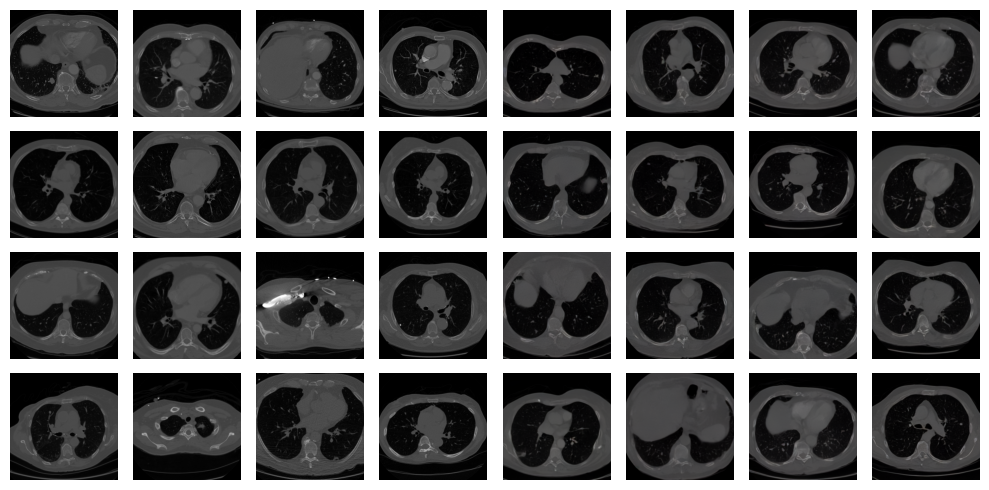

In [17]:
def display_real_vs_fake(real, fake, nrows, ncols):
    import random
    assert nrows % 2 == 0 and ncols % 2 == 0
    
    # Create a figure for the grid
    fig, axes = plt.subplots(nrows, ncols, figsize=(10, 5))

    cases_per_setting = nrows * ncols // 2
    real_idx = random.sample(range(real.shape[0]), cases_per_setting)
    fake_idx = random.sample(range(fake.shape[0]), cases_per_setting)
    real_ims = real[real_idx]
    fake_ims = fake[fake_idx]
    images = []
    for i in range(nrows):
        images.append(real_ims[i*ncols//2:i*ncols//2 + ncols//2])
        images.append(fake_ims[i*ncols//2:i*ncols//2 + ncols//2])
    images = np.concatenate(images)
    
    # Iterate over the images and display them in the grid
    for i, ax in enumerate(axes.flat):
        image = images[i]
        # Check if images have 3 channels and handle them correctly
        if image.shape[0] == 3:
            # Transpose the image from (3, 32, 32) to (32, 32, 3)
            image = np.transpose(image, (1, 2, 0))

        ax.imshow(image)
        ax.axis('off')  # Hide the axes

    #plt.subplots_adjust(wspace=0.1, hspace=0.1)
    plt.tight_layout()
    plt.show()

display_real_vs_fake(real_images, fake_images, 4, 8)

#### Figure 2 - Real vs Synthetic images with mask

This figure should show a 4x4 | 4x4 plot of real vs synthetic cool images

/tmp/ipykernel_1456136/3167016466.py:84: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.text(5, 15, s=abc[i], fontsize = 18, bbox=dict(fill=True, color="white", edgecolor='black', linewidth=2))


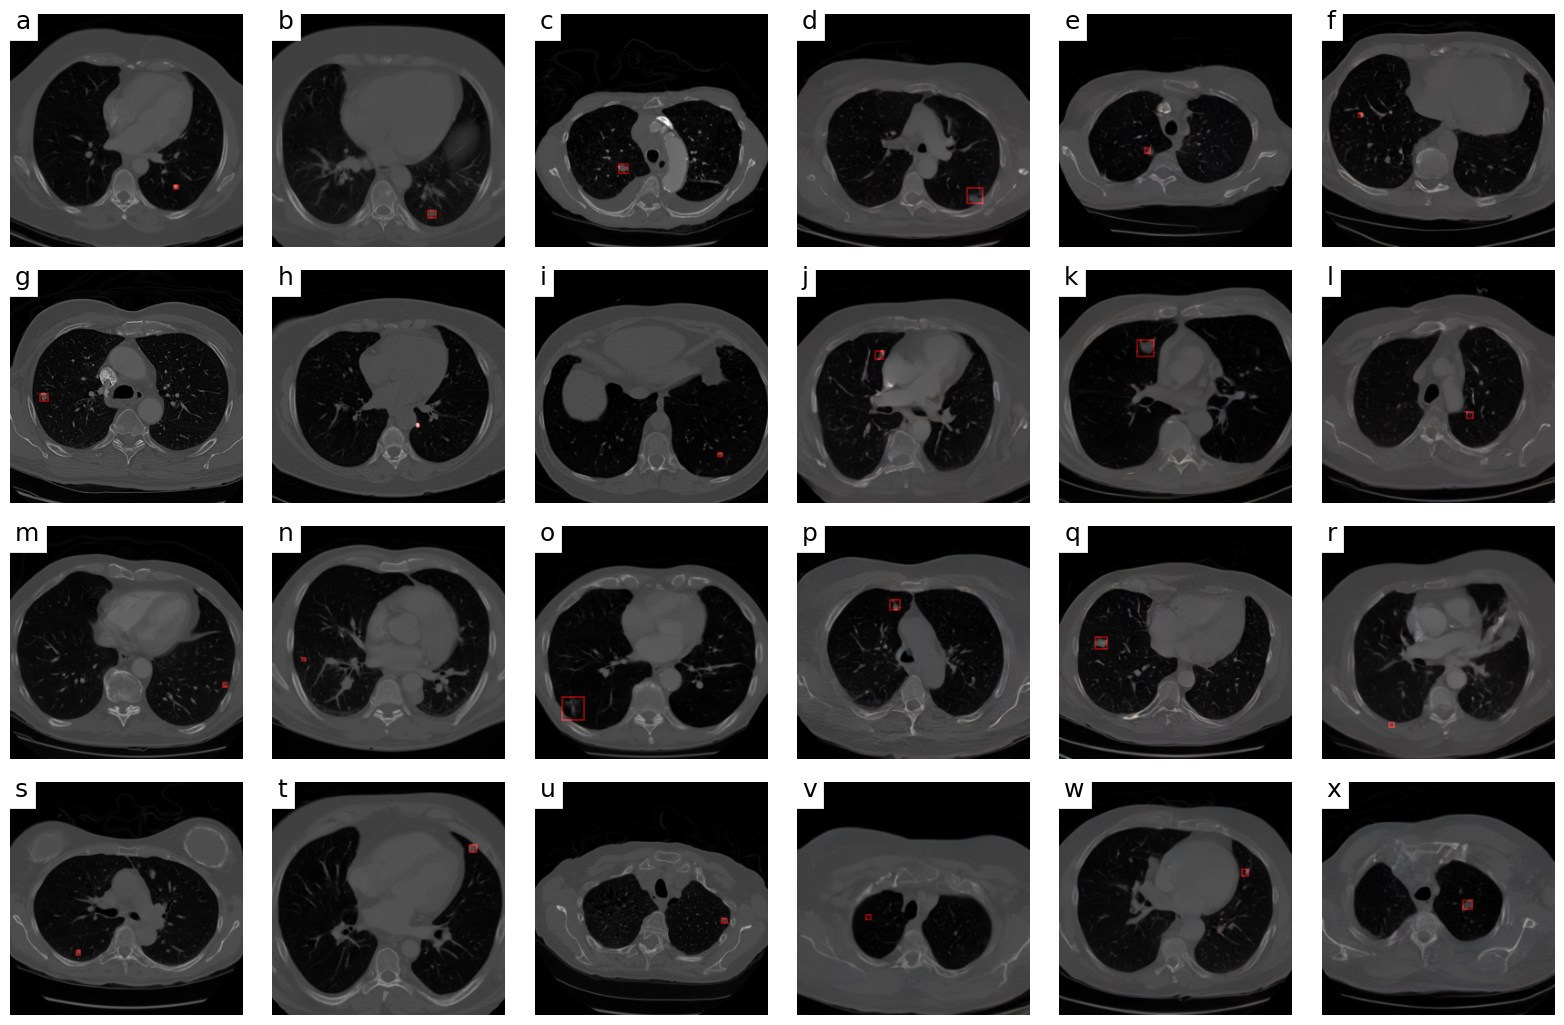

In [12]:
import random
import sys
sys.path.insert(1, './src')

from utils_lidc import *

real_images_dir = "/home/ubuntu/projects/phase-iv-ai/DiffusionFastForward/paper_dataset_all/nodules_6mm_512x512"
masks_dir = real_images_dir.replace("nodules", "masks") + "_sq"

resolution = 256
img_tf = transforms.Resize(resolution, interpolation=transforms.InterpolationMode.BILINEAR)
mask_tf = transforms.Resize(resolution, interpolation=transforms.InterpolationMode.NEAREST)

nrows = 4
ncols = 6
cases_per_setting = nrows * ncols // 2


# (1) read real images
real_img_paths = glob.glob(real_images_dir + "/*.png")
real_idx = random.sample(range(len(real_img_paths)), cases_per_setting)

images = []
masks = []
for p in np.array(real_img_paths)[real_idx]:
    
    # read image
    img = np.array(Image.open(p))
    img = torch.from_numpy(img).permute(2, 0, 1).type(torch.float32) / 255.
    if img.shape[1] != resolution:
        img = img_tf(img)
    
    # read mask
    mask_p = masks_dir + f"/{os.path.basename(p)}"
    mask = np.array(Image.open(mask_p))
    mask[mask<200] = 0
    mask = torch.from_numpy(mask).type(torch.float32) / 255.
    if len(mask.shape) == 3:
        mask = mask.permute(2, 0, 1)
    else:
        mask = mask.unsqueeze(0)
    if mask.shape[1] != resolution:
        mask = mask_tf(mask)
    assert len(torch.unique(mask)) == 2
        
    images.append(img.permute(1, 2, 0).cpu().numpy())
    masks.append(mask.permute(1, 2, 0).cpu().numpy())
    
images = np.stack(images)
masks = np.stack(masks)   
real_cool_imgs = merge_images_with_masks(images, masks)

# (2) read fake images
exp_id = "2024-07-13_10-10-26_FINAL_CCIA24_model1_selfattention_locmask"
#exp_id = "2024-07-12_19-57-59_FINAL_CCIA24_model3_crossattention_locmask_noduleattributes_maskv2"
#exp_id = "2024-07-12_10-03-18_FINAL_CCIA24_model2_crossattention_locmask_maskv2"

model_path = f"/media/share/Datasets/diffusers_out/{exp_id}"
fake_images_dir = f"{model_path}/fid_synthetic/cool_ims"

fake_img_paths = glob.glob(fake_images_dir + "/*.png")
fake_idx = random.sample(range(len(fake_img_paths)), cases_per_setting)
images = []
for p in np.array(fake_img_paths)[fake_idx]:
    img = np.array(Image.open(p)) / 255.
    images.append(img)
fake_cool_imgs = np.stack(images)

images = []
for i in range(nrows):
    images.append(real_cool_imgs[i*ncols//2:i*ncols//2 + ncols//2])
    images.append(fake_cool_imgs[i*ncols//2:i*ncols//2 + ncols//2])
images = np.concatenate(images)

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 13))
abc = list('abcdefghijklmnopqrstuvwxyz')
# Iterate over the images and display them in the grid
for i, ax in enumerate(axes.flat):
    image = images[i]
    # Check if images have 3 channels and handle them correctly
    if image.shape[0] == 3:
        # Transpose the image from (3, 32, 32) to (32, 32, 3)
        image = np.transpose(image, (1, 2, 0))
    ax.text(5, 15, s=abc[i], fontsize = 18, bbox=dict(fill=True, color="white", edgecolor='black', linewidth=2))
    ax.imshow(image)
    ax.axis('off')  # Hide the axes

plt.subplots_adjust(wspace=0.1, hspace=0.1)
#plt.tight_layout()
plt.show()

#### Figure 3 - Real vs Synthetic nodules

This figure should show a 4x4 | 4x4 plot of real vs synthetic nodules

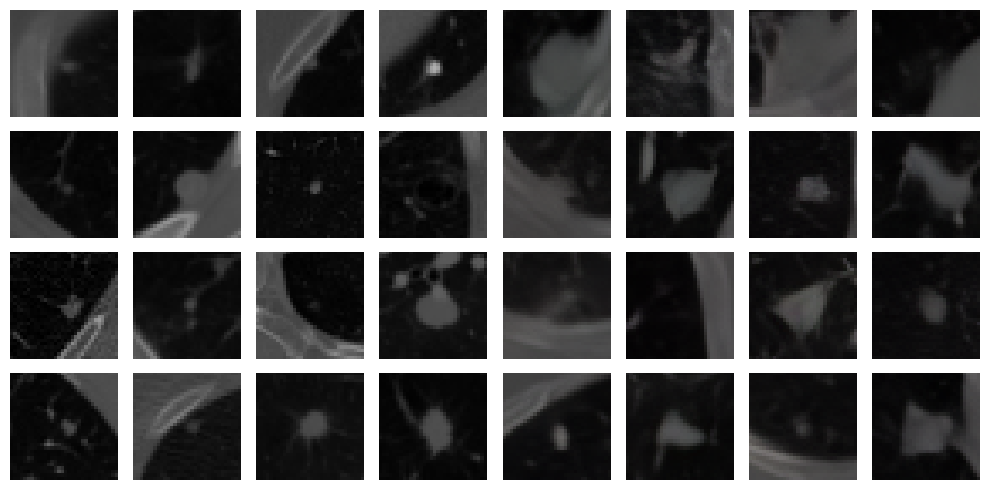

In [18]:
display_real_vs_fake(real_nodules, fake_nodules, 4, 8)

### For each real image, retrieve the most similar synthetic image

- Then check if the nodule attributes are correlated
- Warning: This is quite slow

In [21]:
from torchmetrics.functional import structural_similarity_index_measure as ssim
from tqdm import tqdm
import random


def compute_correlation_between_synthetic_and_real_attributes(fake_atts, real_atts):
    feature_labels = ["sphericity", "lobulation", "spiculation", "margin", "texture"]
    real_atts_vec, fake_atts_vec = [], []
    for k in feature_labels:
        parse_float = lambda x: np.mean(string2array(x, dtype=np.float32))
        real_atts_vec.append(parse_float(real_atts[k]))
        fake_atts_vec.append(fake_atts[k])
    real_atts_vec = np.array(real_atts_vec)
    fake_atts_vec = np.array(fake_atts_vec)
    vec_diff = np.sqrt(np.sum((real_atts_vec - fake_atts_vec)**2))
    return vec_diff

def tensor2numpy(t):
    return t.permute(1, 2, 0).detach().cpu().numpy()

def normalize_im(im):
    return (im +1)/2



best_ssim_metrics = []
best_indices = []
vec_diffs = []
for i in tqdm(np.arange(real_nodules.shape[0])[:20]):
    src_idx = i
    study_im = real_nodules[src_idx].unsqueeze(0)

    all_ssim = []
    all_mse = []
    for sample in fake_nodules:
        candidate_im = sample.unsqueeze(0)
        ssim_val = ssim(study_im, candidate_im)
        all_ssim.append(ssim_val)
        mse_val = torch.sum((study_im - candidate_im)**2)
        all_mse.append(mse_val)

    best_ssim_idx = int(np.argmax(np.array(all_ssim)))
    best_mse_idx = int(np.argmin(np.array(all_mse)))

    best_idx = best_ssim_idx

    fake_atts = fake_metadata[best_idx]
    real_atts = real_metadata[src_idx]
    vec_diff = compute_correlation_between_synthetic_and_real_attributes(fake_atts, real_atts)
    
    best_ssim_metrics.append(all_ssim[best_idx])
    best_indices.append(best_idx)
    vec_diffs.append(vec_diff)

fig = plt.figure(figsize=(10, 10))
sorted_idx = np.argsort(vec_diffs)
a = vec_diffs - np.mean(vec_diffs)
plt.plot(a[sorted_idx], c="blue", label="attribute differences")
b = np.array(best_ssim_metrics) #(best_ssim_metrics - np.mean(best_ssim_metrics))
plt.plot(b[sorted_idx], c="red", label="ssim")
plt.legend()
plt.show()

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:58<00:00,  2.93s/it]


### Check the effect of downsampling and loss of resolution

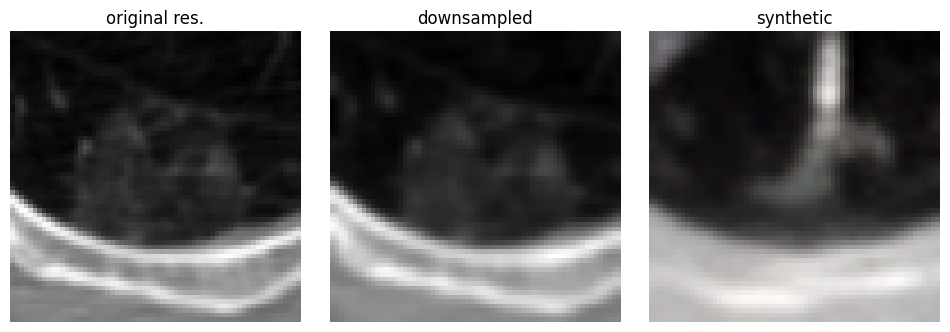

In [67]:
def read_nodule_image_at_original_res(p, masks_dir):
    img = np.array(Image.open(p))
    img = torch.from_numpy(img).permute(2, 0, 1).type(torch.float32) / 255.

    # extract nodule
    mask_p = masks_dir + f"/{os.path.basename(p)}"
    mask = np.array(Image.open(mask_p))
    mask[mask<200] = 0
    mask = torch.from_numpy(mask).type(torch.float32) / 255.
    if len(mask.shape) == 3:
        mask = mask.permute(2, 0, 1)
    else:
        mask = mask.unsqueeze(0)
    center_col, center_row = find_mask_center(mask[0])
    s = 64
    min_row = max(center_row - s//2, 0)
    max_row = min(center_row + s//2, img.shape[1]-1)
    min_col = max(center_col - s//2, 0)
    max_col = min(center_col + s//2, img.shape[2]-1)
    assert min_row < max_row and min_col < max_col
    nodule = img[:, min_row:max_row , min_col:max_col]
    return nodule



real_images_dir = "/home/ubuntu/projects/phase-iv-ai/DiffusionFastForward/paper_dataset_all/nodules_6mm_512x512"
study_idx = 1

img_tf = transforms.Resize((64, 64), interpolation=transforms.InterpolationMode.BILINEAR)

fake_img = img_tf(fake_nodules[best_indices[study_idx]])
real_img = img_tf(real_nodules[study_idx].squeeze())

original_img_path = real_images_dir + "/" + real_metadata[study_idx]["file_name"]
masks_dir = real_images_dir.replace("nodules", "masks") + "_sq"
assert os.path.exists(original_img_path)
nodule = read_nodule_image_at_original_res(original_img_path, masks_dir)
images = [tensor2numpy(nodule), tensor2numpy(real_img), tensor2numpy(fake_img)]

normalize = True
def min_max_norm(x):
    return (x - x.min()) / (x.max() - x.min())
if normalize:
    images = [min_max_norm(im) for im in images]

labels = ["original res.", "downsampled", "synthetic"]
fig, axes = plt.subplots(1, 3, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    image = images[i]
    # Check if images have 3 channels and handle them correctly
    if image.shape[0] == 3:
        # Transpose the image from (3, 32, 32) to (32, 32, 3)
        image = np.transpose(image, (1, 2, 0))
    ax.imshow(image)
    ax.title.set_text(labels[i])
    ax.axis('off')  # Hide the axes
    #if i == 1:
    #    ax.title.set_text(f"MSE att = {vec_diff:.2f}")
plt.subplots_adjust(wspace=0.1, hspace=0.1)
plt.show()

In [28]:
real_metadata[study_idx]

{'area': '823',
 'bbx': '334 406 326 398 171 199',
 'file_name': 'LIDC-IDRI-0002-001-185.png',
 'lobulation': '1. 1. 0. 0.',
 'margin': '1. 2. 0. 0.',
 'pixel_spacing': '0.68164',
 'slice_spacing': '1.25000',
 'sphericity': '5. 3. 0. 0.',
 'spiculation': '1. 1. 0. 0.',
 'texture': '1. 2. 0. 0.',
 '0ID': 1}

In [29]:
fake_metadata[best_indices[study_idx]]

{'0ID': 1108,
 'area': 144,
 'file_name': '01108.png',
 'lobulation': 3,
 'margin': 5,
 'sphericity': 2,
 'spiculation': 3,
 'texture': 3}

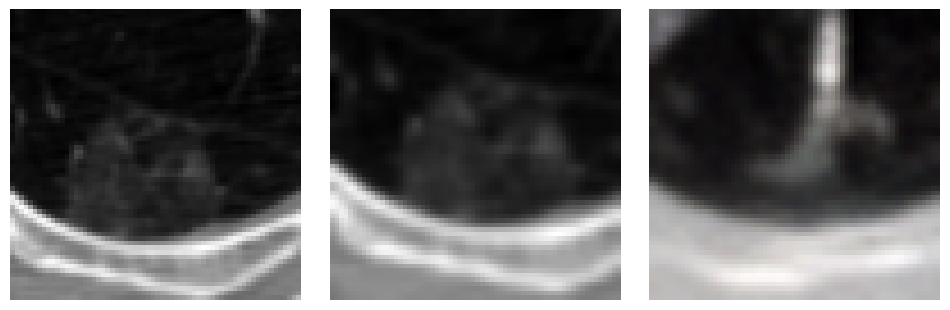

In [66]:
import pylidc as pl
from generate_paper_dataset import normalize_lidc_img

def read_nodule_at_original_res(p):
    
    patient_id = "-".join(p.split("/")[-1].split("-")[:3])
    metadata_p = "/home/ubuntu/projects/phase-iv-ai/DiffusionFastForward/paper_dataset_all/nodules_6mm/metadata.jsonl"
    metadata = read_jsonl(metadata_p)
    for m in metadata:
        if m["file_name"] == p.split("/")[-1]:
            bbx = m["bbx"]
    
    LIDC_data_path = "/media/share/Datasets/LIDC-IDRI/LIDC-IDRI"
    scan = pl.query(pl.Scan).filter(pl.Scan.patient_id == patient_id).first()
    vol = scan.to_volume(verbose=False)
    
    bbx = string2array(bbx, dtype=np.int16)
    k = int(0.5*(bbx[5] - bbx[4]))
    img = normalize_lidc_img(vol[:, :, bbx[4] + k])
    img = torch.from_numpy(img).permute(2, 0, 1)
    
    # extract nodule
    min_row = bbx[0]
    max_row = bbx[1]
    min_col = bbx[2]
    max_col = bbx[3]
    assert min_row < max_row and min_col < max_col
    nodule = img[:, min_row:max_row, min_col:max_col]
    return nodule

real_images_dir = "/home/ubuntu/projects/phase-iv-ai/DiffusionFastForward/paper_dataset_all/nodules_6mm_512x512"
study_idx = 1
original_img_path = real_images_dir + "/" + real_metadata[study_idx]["file_name"]
masks_dir = real_images_dir.replace("nodules", "masks") + "_sq"
bbx = real_metadata[study_idx]["bbx"]
nodule = read_nodule_at_original_res(original_img_path)

real_img = img_tf(real_nodules[study_idx].squeeze())
images = [tensor2numpy(nodule), tensor2numpy(real_img), tensor2numpy(fake_img)]

normalize = True
def min_max_norm(x):
    return (x - x.min()) / (x.max() - x.min())
if normalize:
    images = [min_max_norm(im) for im in images]

fig, axes = plt.subplots(1, 3, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    image = images[i]
    # Check if images have 3 channels and handle them correctly
    if image.shape[0] == 3:
        # Transpose the image from (3, 32, 32) to (32, 32, 3)
        image = np.transpose(image, (1, 2, 0))
    ax.imshow(image)
    ax.axis('off')  # Hide the axes
    #if i == 1:
    #    ax.title.set_text(f"MSE att = {vec_diff:.2f}")
plt.subplots_adjust(wspace=0.1, hspace=0.1)
plt.show()